In [170]:
library(xgboost)
library(lime)


library(shapper)


# Load necessary libraries
library(caret)
library(pROC)  # For AUC-ROC calculation

library(car)
library(glmnet)
library(GGally)
library(ComplexHeatmap)
library(ggplotify)
library(cowplot)
library(caret)
library(UpSetR)
library(pROC)
library(ggfortify)

library(readxl)
library(ggfortify)
library(edgeR)
library(ggpubr)
library(ggrepel)
library(randomForest)
library(ggplotify)
library(RColorBrewer)
library(pROC)
library(data.table)


In [171]:
## Load and parse the 242 lipids from BECAME

In [259]:
## Read excel 
became = data.frame(t(read_xlsx('../data/BECAME1_LipidomicData_lipidesidentifiés.xlsx',sheet=1)))

## Remove the first 10 columns (not lipids)
became_num = became[-c(1:10),]

## Cast data to numeric type 
rownames(became_num) = paste0('X',rownames(became_num))
for(i in 1:ncol(became_num)){became_num[,i]=as.numeric(became_num[,i])}

In [271]:
## Read previously processed data 
scaled_df = read.csv('../data/merged_dataset.csv')
meta = read.csv('../data/merged_dataset_meta.csv')
response_name = 'cluster'

## Subset only the patients from the BECAME cohort
became_data = scaled_df[rownames(subset(meta,cohort=='BECAME' & group=='B1')),]

In [272]:
## Subset the metadata 
became_meta = meta[rownames(became_data),]

## Log transform the intensities 
#became_data = data.frame(scale(log(became_num[rownames(became_data),])))
became_data$response_var = as.factor(as.numeric(became_meta[rownames(became_data),response_name]=='B1'))

## Create train/test indices 
index <- createDataPartition(became_data$response_var, p = 0.7, list = FALSE)

## Define training data 
became_data_train = became_data[index,]

ERROR: Error in createDataPartition(became_data$response_var, p = 0.7, list = FALSE): y must have at least 2 data points


## Random Forest 

In [268]:
## Define formula, ie explain B1 cluster with all lipids 
formula <- response_var~.

## Train a Random Forest classifier
rf_model_allClusters <- randomForest(formula, 
                         data = became_data_train, 
                         ntree = 1000)

## Extract predictions and print confusion table 
predictions_became <- predict(rf_model_allClusters, became_data[-index,], type = "response")
table(predictions_became, became_data[-index,'response_var'])

## Extract importance of each lipid for classifier 
var_importance <- data.frame(importance(rf_model_allClusters))
var_importance$id = rownames(var_importance)

## Order by importance 
id = rownames(var_importance)
var_importance <- data.frame(importance(rf_model_allClusters))
rownames(var_importance) = id
var_importance$id = rownames(var_importance)
var_importance = var_importance[order(-var_importance$MeanDecreaseGini),]

                  
predictions_became  0  1
                 0 25 13
                 1  5  9

In [263]:
## Define function to quickly check the accuracy of a random forest trained with a subset of lipids 
make_rf<-function(keep){

    formula <- response_var~.
    
    rf_model_allClusters <- randomForest(formula, 
                             data = became_data_train[,c(keep,'response_var')], 
                             ntree = 1000)
    
    predictions_became <- predict(rf_model_allClusters, became_data[-index,keep], type = "response")
    accuracy_became <- mean(predictions_became == became_data[-index,'response_var'])
    return(accuracy_became)
}

In [264]:
### This part is aiming at reducing the number of features:

## Create a correlation matrix 
## Iterate over all possible number of correlated modules (1:n)
## Find n modules 
## Within the module, find all the lipids that are correlated (R>.6) and keep the one with the highest importance score 
## Keep all uncorrelated features from the model 

In [265]:

# Step 1: Calculate correlation matrix
cor_matrix <- data.frame(cor(became_data_train[,grepl('^X',colnames(became_data_train))]))

# Step 2: Perform hierarchical clustering
dendrogram <- hclust(dist(1 - cor_matrix))

cor_matrix$id = rownames(cor_matrix)

# Step 3: Cut the dendrogram to form clusters
num_clusters <- 2:(ncol(cor_matrix)-1)
plots = list()
dist_mat = data.frame()
signatures = list()
accuracies = c()
for(n in num_clusters){
    
    # Cut dendrogram 
    clusters <- cutree(dendrogram, n)
    keeps = c()
    
    # Iterate over all clusters
    for(i in 1:n){
        
        # Find the lipids in each cluster 
        clus_names = names(clusters[clusters==i])
        
        # melt the correlation matrix to have a dataframe with 3 columns: lipid1, lipid2, corr_coef
        m = na.omit(reshape2::melt(cor_matrix[clus_names,c('id',clus_names)],id.var='id'))
        
        # Keep only the pairs with corr > .6
        correlated = unique(subset(m,value>0.6)[,1])
        
        # If there are correlated features... 
        if(length(correlated)>0){
            
            # Create a new vector tmp that is ordered by importance 
            tmp = rownames(var_importance) %in% correlated
            names(tmp) = rownames(var_importance)
            tmp = tmp[tmp==1]
            
            # Keep the first element (most important) and all other lipids that were not correlated 
            keep = c(names(tmp)[1],clus_names[!clus_names%in%correlated])
        }else{
            keep = c(clus_names)
        }
        keeps = c(keeps,keep)
    }
    keeps = na.omit(keeps) 
    signatures[[as.character(n)]] = keeps
    acc = make_rf(keeps)
    accuracies = c(accuracies,acc)
    
}

accuracies = data.frame(accuracies)
accuracies$modules = num_clusters


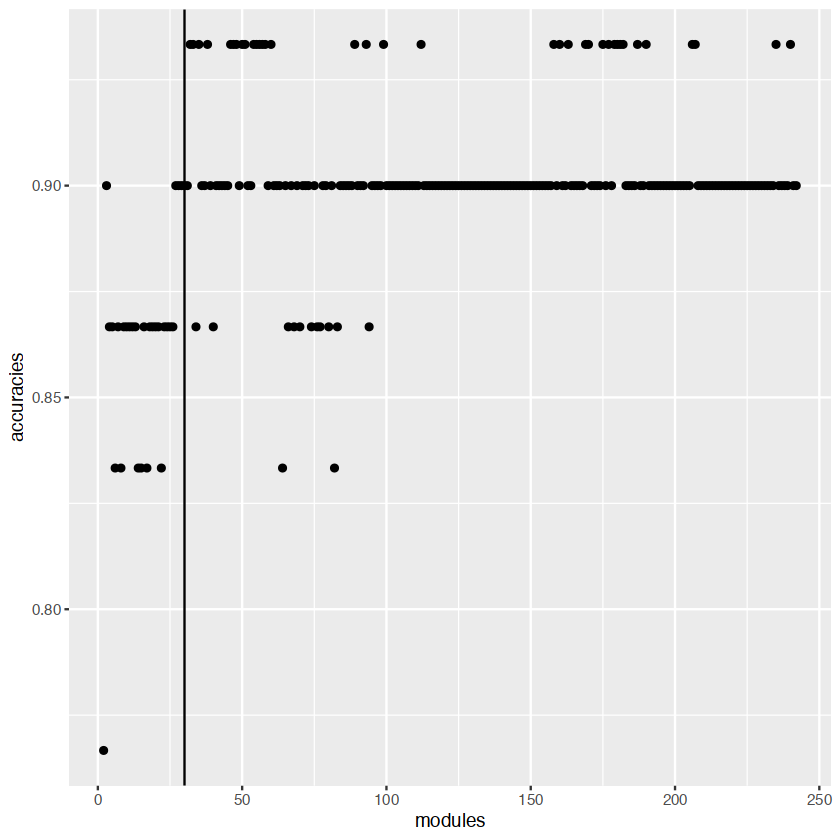

In [229]:
ggplot(accuracies,aes(modules,accuracies))+geom_point()+geom_vline(xintercept=30)

In [230]:
formula <- response_var~.

# Train the Random Forest classifier
rf_model_allClusters <- randomForest(formula, 
                         data = became_data_train[,c(signatures[['5']],'response_var')], 
                         ntree = 1000)

predictions_became <- predict(rf_model_allClusters, became_data[-index,c(signatures[['5']],'response_var')], type = "response")
table(predictions_became, became_data[-index,'response_var'])

                  
predictions_became  0  1
                 0 23  2
                 1  0  5

## Logistic Regression (forward-backward steps)

In [233]:

lipids = colnames(became_data)[grepl('^X',colnames(became_data))]

# Create a formula for the null model
null_model_formula <- as.formula(paste("response_var ~ 1"))
# Create a formula for lipids
lipids_formula <- as.formula(paste("response_var ~", paste(lipids, collapse = " + ")))


# Step 2: Forward-backward feature selection with BIC on lipids
null_model <- glm(null_model_formula, data = became_data_train, family = 'binomial')
lipids_model <- step(null_model, direction = "both", 
                     scope = list(lower = null_model_formula, upper = lipids_formula), 
                     k = log(nrow(became_data_train)),trace = FALSE) 


predictions_became <- predict(lipids_model, newdata =  became_data[-index,], type = "response")
table(round(predictions_became), became_data[-index,'response_var'])

   
     0  1
  0 19  1
  1  4  6

In [234]:
signatures[['30']]

[1] "X2"   "X8"   "X107" "X12"  "X56"  "X97"  "X88"  "X50"  "X42"  "X121"
[11] "X39"  "X37"  "X115" "X87"  "X80"  "X68"  "X71"  "X173" "X129" "X134"
[21] "X235" "X174" "X160" "X169" "X170" "X186" "X191" "X228" "X210" "X215"

In [232]:
summary(lipids_model)


Call:
glm(formula = response_var ~ X214 + X149 + X190 + X227, family = "binomial", 
    data = became_data_train)

Deviance Residuals: 
       Min          1Q      Median          3Q         Max  
-1.013e-04  -2.100e-08  -2.100e-08  -1.100e-08   7.145e-05  

Coefficients:
            Estimate Std. Error z value Pr(>|z|)
(Intercept)  -165.14   51685.48  -0.003    0.997
X214         -198.72   56632.52  -0.004    0.997
X149          -71.28   38920.84  -0.002    0.999
X190         -100.99   64161.91  -0.002    0.999
X227           67.46   25450.08   0.003    0.998

(Dispersion parameter for binomial family taken to be 1)

    Null deviance: 8.0976e+01  on 71  degrees of freedom
Residual deviance: 2.4796e-08  on 67  degrees of freedom
AIC: 10

Number of Fisher Scoring iterations: 25


## LASSO logistic regression 

In [235]:
x = became_data[index,grepl('^X',colnames(became_data))]
y = became_data[index,]$response_var
cv_model <- cv.glmnet(as.matrix(x), y, alpha = .5,family='binomial')

lambda_min <- cv_model$lambda.min
lambda_1se <- cv_model$lambda.1se

min_model <- glmnet(as.matrix(x), y, alpha = .5, lambda = lambda_min, family='binomial')
co = coef(min_model)[,1]
lambda_min_predictors = names(co[abs(co)>0])

se_model <- glmnet(as.matrix(x), y, alpha = .5, lambda = lambda_1se, family='binomial')
co = coef(se_model)[,1]
lambda_se_predictors = names(co[abs(co)>0])

preds =  predict(se_model, s = lambda_1se, newx = as.matrix(became_data[-index,grepl('^X',colnames(became_data))]),type='response')
y_predicted <- table(became_data[-index,]$response_var,round(preds))

y_predicted

preds =  predict(min_model, s = lambda_1se, newx = as.matrix(became_data[-index,grepl('^X',colnames(became_data))]),type='response')
y_predicted <- table(became_data[-index,]$response_var,round(preds))

y_predicted

   
     0  1
  0 23  0
  1  2  5

   
     0  1
  0 23  0
  1  0  7

In [239]:
coef(min_model)

243 x 1 sparse Matrix of class "dgCMatrix"
                       s0
(Intercept) -2.5038885874
X1           0.2245301840
X2           .           
X3           .           
X4           .           
X5           0.0740932764
X6           .           
X7           .           
X8           .           
X9           .           
X10          .           
X11          .           
X12          .           
X13          .           
X14          .           
X15          .           
X16          .           
X17          .           
X18          .           
X19          0.0510997005
X20          .           
X21          .           
X22          .           
X23          .           
X24          .           
X25          0.0753184005
X26          .           
X27          .           
X28          .           
X29          .           
X30          .           
X31          .           
X32         -0.1762327853
X33          .           
X34          .           
X35          .       

In [236]:
lambda_se_predictors
lambda_min_predictors

[1] "(Intercept)" "X1"          "X5"          "X19"         "X32"        
 [6] "X58"         "X87"         "X92"         "X93"         "X94"        
[11] "X97"         "X105"        "X107"        "X112"        "X113"       
[16] "X121"        "X127"        "X129"        "X149"        "X152"       
[21] "X160"        "X166"        "X167"        "X181"        "X186"       
[26] "X188"        "X190"        "X195"        "X197"        "X200"       
[31] "X213"        "X214"

[1] "(Intercept)" "X1"          "X5"          "X19"         "X25"        
 [6] "X32"         "X48"         "X58"         "X87"         "X92"        
[11] "X93"         "X94"         "X96"         "X97"         "X107"       
[16] "X112"        "X113"        "X121"        "X122"        "X127"       
[21] "X129"        "X141"        "X149"        "X152"        "X160"       
[26] "X166"        "X167"        "X181"        "X186"        "X190"       
[31] "X195"        "X197"        "X200"        "X201"        "X209"       
[36] "X213"        "X214"        "X226"

## XGBoost

In [240]:
X <- became_data[index,grepl('^X',colnames(became_data))]
y <- as.numeric(as.character(became_data[index,]$response_var))

dtrain <- xgb.DMatrix(data = as.matrix(X), label = y)

# Set parameters
params <- list(
  objective = "binary:logistic",
  eval_metric = "logloss"
)

# Train the XGBoost model
model <- xgboost(data = dtrain, 
                 params = params, 
                 nrounds = 50,
                 verbose=0)

X_test <- became_data[-index,grepl('^X',colnames(became_data))]
y_test <- factor(as.numeric(as.character(became_data[-index,]$response_var)))

# Predictions on the test set
predictions <- predict(model, as.matrix(X_test))

# Convert predicted probabilities to class labels (binary classification)
predicted_labels <- ifelse(predictions > 0.5, 1, 0)
table(predicted_labels,y_test)

importance <- data.frame(xgb.importance(model = model))
rownames(importance) = importance[,1]

                y_test
predicted_labels  0  1
               0 23  2
               1  0  5

In [241]:
final_signatures = list()

In [242]:
final_signatures[['RF']] = signatures[['30']]

In [243]:
final_signatures[['step']] = names(coef(lipids_model))[-1]

In [244]:
final_signatures[['LASSO_min']] = lambda_min_predictors[-1]

In [245]:
final_signatures[['LASSO_1se']] = lambda_se_predictors[-1]

In [246]:
final_signatures[['XGBoost']] = rownames(head(importance,20))

In [247]:
library(UpSetR)

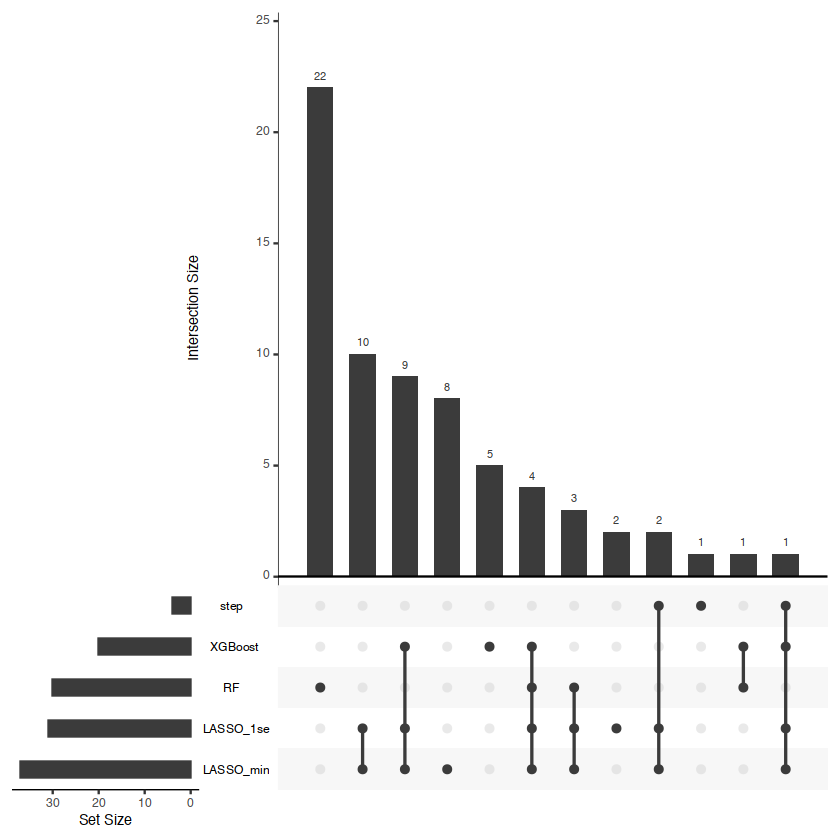

In [248]:
upset(fromList(final_signatures),order.by='freq')

In [249]:
threshold = .6
vec = rep(0, length(unique(unlist(final_signatures))))
names(vec) = unique(unlist(final_signatures))
for(i in unique(unlist(final_signatures))){
    for(ele in 1:length(final_signatures)){
      if(i %in% final_signatures[[ele]]){
         vec[i]=vec[i]+1   
      }
    }
}
vec = vec/length(final_signatures)
common_elements_se = names(vec[vec>=threshold])
common_elements_se = common_elements_se[common_elements_se!='(Intercept)']


In [250]:
as.character(became[3,common_elements_se])

[1] "PC(16:1_22:6)"                "PC(15:1/20:4) /PC(15:0/20:5)"
 [3] "PC(22:6_20:4)"                "PC(O-20:2/20:4)"             
 [5] "PE(O-18:0/20:4)"              "SM(d18:2/23:0)"              
 [7] "TG50:4"                       "TG54:8"                      
 [9] "SM(d16:1/22:0)"               "TG50:5"                      
[11] "C14:0 Car"                    "CE18:1"                      
[13] "PC(14:0_20:5)"                "PC(14:0_22:6)"               
[15] "PE(O-16:0/22:6)"              "SM(d18:1/21:0)"              
[17] "TG51:4"                       "TG52:6"                      
[19] "TG54:7"

In [252]:
length(common_elements_se)

[1] 19

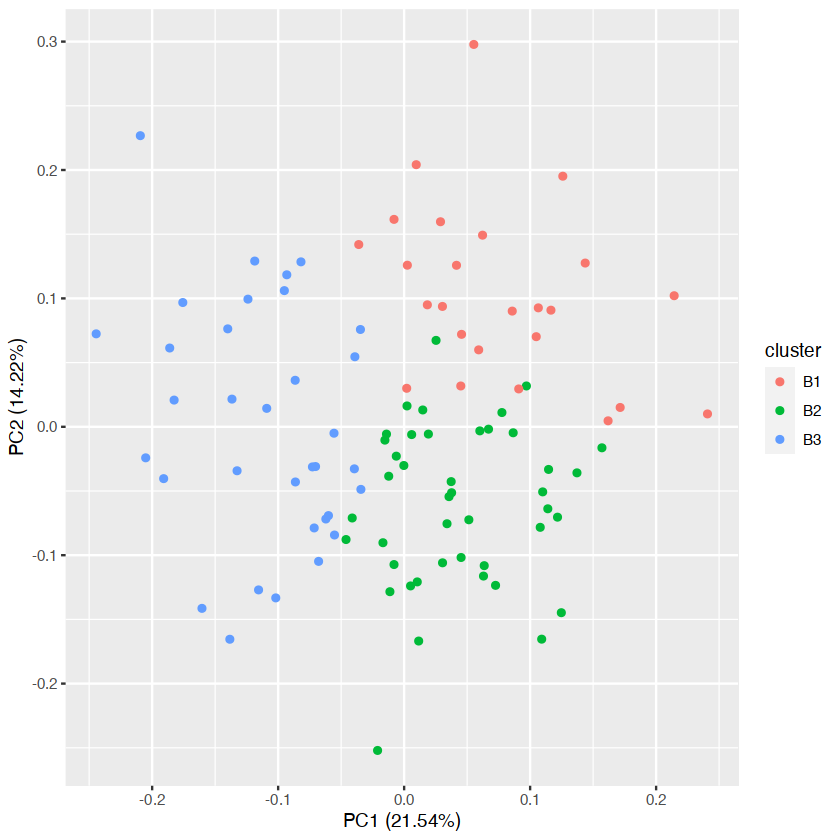

In [211]:
autoplot(prcomp(scale(became_data[,grepl('^X',colnames(became_data))])),
         data=meta[rownames(became_data),],col='cluster')

In [275]:
length(final_signatures[['LASSO_']])

[1] 31

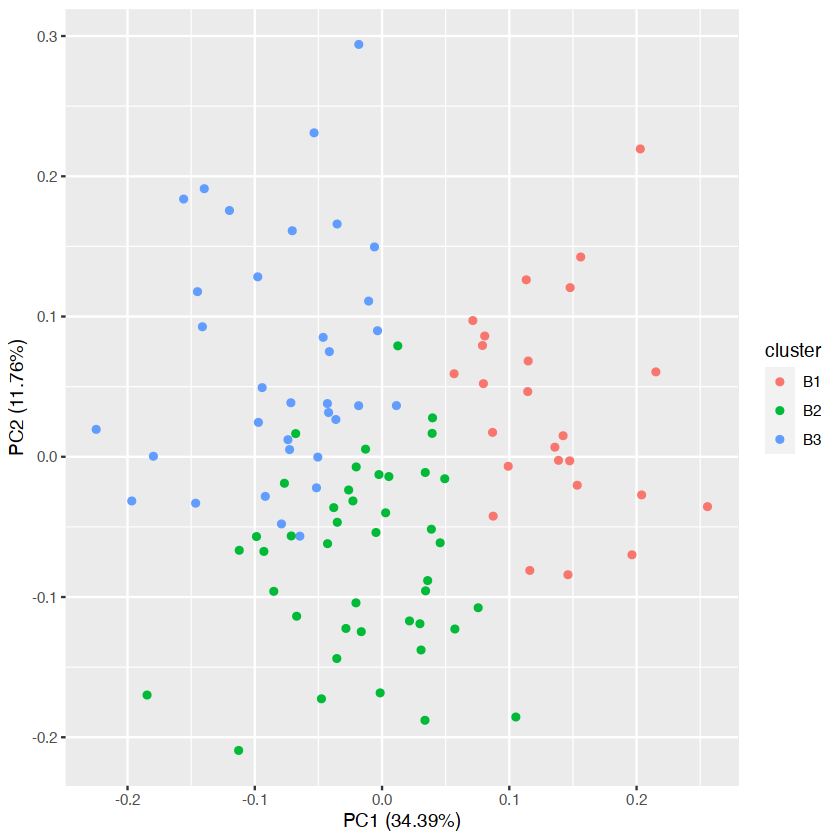

In [257]:
autoplot(prcomp(scale(became_data[,final_signatures[['LASSO_min']]])),
         data=meta[rownames(became_data),],col='cluster')

In [213]:
miracle_data = scaled_df[rownames(subset(meta,cohort=='MIRACLE')),]
miracle_meta = meta[rownames(miracle_data),]


In [32]:
rfe_features = c("X3" ,  "X144", "X58" , "X146" ,"X132" ,"X83" , "X64" , "X143" ,"X133", "X110",
"X37" , "X62" , "X128", "X16" , "X63" , "X121", "X38" , "X71" , "X61" , "X11", 
"X51" , "X104", "X8"  , "X73" , "X119", "X97" , "X22" , "X49" , "X154", "X1" , 
"X142" ,"X39" , "X46" , "X78" , "X6" ,  "X29" , "X84" , "X5")

In [33]:
formula <- response_var~.

# Train the Random Forest classifier
rf_model_allClusters <- randomForest(formula, 
                         data = became_data_train[,c(rfe_features,'response_var')], 
                         ntree = 1000)

predictions_became <- predict(rf_model_allClusters, became_data[-index,c(rfe_features,'response_var')], type = "response")
table(predictions_became, became_data[-index,'response_var'])

                  
predictions_became  0  1
                 0 22  0
                 1  1  7

In [221]:
signatures[['40']]

[1] "X2"   "X8"   "X10"  "X12"  "X56"  "X97"  "X19"  "X112" "X88"  "X50" 
[11] "X42"  "X114" "X39"  "X37"  "X115" "X53"  "X87"  "X80"  "X76"  "X68" 
[21] "X71"  "X73"  "X91"  "X121" "X107" "X173" "X113" "X129" "X134" "X235"
[31] "X174" "X160" "X169" "X170" "X179" "X186" "X191" "X228" "X210" "X215"

In [222]:
predictions_miracle <- predict(rf_model_allClusters, became_data[,signatures[['40']]], type = "response")
table(predictions_miracle,meta[,'cluster'])

ERROR: Error in table(predictions_miracle, meta[, "cluster"]): all arguments must have the same length


In [35]:
signatures[['10']]

[1] "X3"   "X71"  "X69"  "X8"   "X73"  "X38"  "X132" "X153" "X99"  "X114"

In [36]:
meta$prediction = predictions_miracle[rownames(meta)]

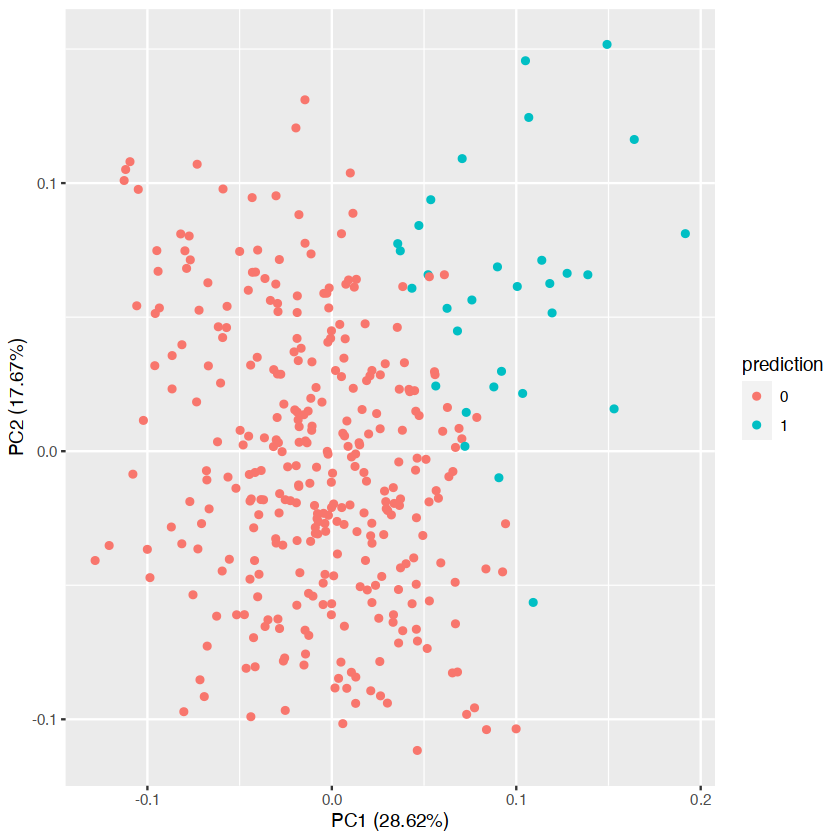

In [37]:
autoplot(prcomp(scaled_df[,rfe_features]),data=meta,col='prediction')